In [19]:
import pandas
import pickle
import numpy 
import os
import sys

sys.path.append("../../")
from utils import read_pattern_json
print (os.getcwd())
pattern_reg_df = read_pattern_json("Combined_Pattern_Registrations.pkl")
pattern_reg_df.head()

/Users/shubhom/Documents/closed_loop_stim/patterns_5k/data/whole_brain_LS19_Dec25


,step_index,step_start_timestamp,pattern_name,pattern_lambda,pattern_flag_start_timestamp,pattern_timing_index,pattern_idx_length,channel,delay_mode,is_oracle,trial
0,0,904114,3903,1.0,900276,0,10,69,-1,False,1
1,0,904114,3903,1.0,900276,0,10,96,0,False,1
2,2,907947,3903,1.0,900276,0,10,30,1,False,1
3,2,907947,3903,1.0,900276,0,10,92,0,False,1
4,3,909884,3903,1.0,900276,0,10,71,0,False,1


In [24]:
pattern_reg_df["is_oracle"].value_counts()

is_oracle
False    88078
True     10050
Name: count, dtype: int64

In [2]:
"""
Quick-start script for loading and inspecting units_export.pkl.
Run this to verify the file structure and browse its contents.
"""
import pickle
from pathlib import Path
import os
import numpy as np
# ── Point this to your pkl file ───────────────────────────────────────────────
pkl_path = Path("units_export.pkl")

# ── Load ──────────────────────────────────────────────────────────────────────
with open(pkl_path, "rb") as f:
    units = pickle.load(f)

# ── Overview ──────────────────────────────────────────────────────────────────
print(f"Total units: {len(units)}")
print(f"Keys (unit IDs): {list(units.keys())[:10]} ...")
print()

# ── Label counts ──────────────────────────────────────────────────────────────
labels = [u["label"] for u in units.values()]
for lbl in sorted(set(labels)):
    print(f"  {lbl}: {labels.count(lbl)} units")
print()

# ── Recordings represented ────────────────────────────────────────────────────
recordings = sorted(set(u["recording"] for u in units.values()))
print(f"Recordings ({len(recordings)}):")
for rec in recordings:
    rec_units = [uid for uid, u in units.items() if u["recording"] == rec]
    print(f"  {rec}: {len(rec_units)} units")
print()

# ── Inspect first unit as example ─────────────────────────────────────────────
uid = 0
u = units[uid]
print(f"Example — unit {uid}:")
print(f"  recording:        {u['recording']}")
print(f"  original_unit_id: {u['original_unit_id']}")
print(f"  label:            {u['label']}")
print(f"  position:         {u['position']}  (shape {u['position'].shape})")
print(f"  spike_train:      {u['spike_train'].shape[0]} spikes, dtype={u['spike_train'].dtype}")
print(f"  first 5 samples:  {u['spike_train'][:5]}")


Total units: 165
Keys (unit IDs): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ...

  good: 157 units
  mua: 8 units

Recordings (30):
  20251218_152916_stim3_sh0.nwb: 1 units
  20251218_152916_stim3_sh1.nwb: 8 units
  20251218_152916_stim3_sh13.nwb: 6 units
  20251218_152916_stim3_sh15.nwb: 2 units
  20251218_152916_stim3_sh17.nwb: 9 units
  20251218_152916_stim3_sh18.nwb: 3 units
  20251218_152916_stim3_sh2.nwb: 2 units
  20251218_152916_stim3_sh20.nwb: 8 units
  20251218_152916_stim3_sh21.nwb: 2 units
  20251218_152916_stim3_sh22.nwb: 5 units
  20251218_152916_stim3_sh23.nwb: 9 units
  20251218_152916_stim3_sh24.nwb: 1 units
  20251218_152916_stim3_sh3.nwb: 4 units
  20251218_152916_stim3_sh30.nwb: 10 units
  20251218_152916_stim3_sh31.nwb: 10 units
  20251218_152916_stim3_sh5.nwb: 6 units
  20251218_152916_stim3_sh7.nwb: 4 units
  ephys_H15M29_sh0.nwb: 5 units
  ephys_H15M29_sh10.nwb: 7 units
  ephys_H15M29_sh11.nwb: 7 units
  ephys_H15M29_sh12.nwb: 10 units
  ephys_H15M29_sh13.nwb: 6 units
  ep

In [25]:

# Convert units_export dict → spikes_df (timestamp, neuron_id) like make_spikes_responses_df produces
rows = []
for uid, u in units.items():
    st = u["spike_train"]
    rows.append(numpy.column_stack([st, numpy.full(len(st), uid, dtype=numpy.int64)]))
spikes_arr = numpy.concatenate(rows, axis=0)
spikes_df = pandas.DataFrame(spikes_arr, columns=["timestamp", "neuron_id"])
spikes_df["timestamp"] = spikes_df["timestamp"].astype(int)
spikes_df["neuron_id"] = spikes_df["neuron_id"].astype(int)
spikes_df.sort_values(by=["timestamp", "neuron_id"], inplace=True)
spikes_df.reset_index(drop=True, inplace=True)
print(f"spikes_df: {len(spikes_df)} spikes, {spikes_df['neuron_id'].nunique()} neurons")
print(spikes_df.head())


spikes_df: 17093730 spikes, 165 neurons
   timestamp  neuron_id
0         41        139
1         79         18
2         96         54
3        121        114
4        137        156


In [26]:

from utils import preprocess_pattern_stimulations_df, trial_breakout_spikes_and_patterns

# Preprocess pattern_df (adds pattern_end_timestamp, aligns to first stim onset)
pattern_df, min_pattern_timestamp = preprocess_pattern_stimulations_df(
    pattern_reg_df, align_to_stim=True
)

# Build channel_to_index from the pattern registrations
channel_to_index = {ch: idx for idx, ch in enumerate(sorted(pattern_df["channel"].dropna().unique()))}

# Spiking neurons
spiking_neurons = spikes_df["neuron_id"].unique()
spiking_neurons.sort()
spiking_neuron_to_index = {neuron: idx for idx, neuron in enumerate(spiking_neurons)}

print(f"Stim channels: {len(channel_to_index)}")
print(f"Spiking neurons: {len(spiking_neurons)}")

# Run trial breakout
pattern_stims, pattern_polarities, spike_responses, timing_to_pattern, unique_trials = (
    trial_breakout_spikes_and_patterns(
        spikes_df,
        pattern_df,
        channel_to_index,
        spiking_neurons=spiking_neurons,
        spiking_neuron_to_index=spiking_neuron_to_index,
    )
)
print(f"Unique patterns: {len(pattern_stims)}, Total trials: {len(spike_responses)}")
print(f"Spike response shape (first trial): {spike_responses[list(spike_responses.keys())[0]].shape}")


Stim channels: 25
Spiking neurons: 165
Unique patterns: 4100, Total trials: 5000
Spike response shape (first trial): (165, 2000)


Neuron positions shape: (165, 3)
X range: [-7750, 7750] µm
Y range: [-1100, 0] µm
Z range: [20, 20] µm


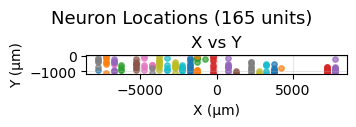

,neuron_id,neuron_index,x_um,y_um,z_um,label,recording
0,0,0,-7750.000000,-900.000000,20.000000,good,20251218_152916_stim3_sh0.nwb
1,1,1,-7250.000000,-1100.000000,20.000000,good,20251218_152916_stim3_sh1.nwb
2,2,2,-7250.000000,-500.000000,20.000001,good,20251218_152916_stim3_sh1.nwb
3,3,3,-7250.000000,-400.000000,20.000000,good,20251218_152916_stim3_sh1.nwb
4,4,4,-7250.000000,-400.000000,20.000000,good,20251218_152916_stim3_sh1.nwb
5,5,5,-7250.000000,-100.000000,20.000000,good,20251218_152916_stim3_sh1.nwb
6,6,6,-7249.999998,-100.000000,20.000000,good,20251218_152916_stim3_sh1.nwb
7,7,7,-7250.000000,0.003665,20.000000,good,20251218_152916_stim3_sh1.nwb
8,8,8,-7250.000000,0.000915,20.000000,good,20251218_152916_stim3_sh1.nwb
9,9,9,-1250.000000,-100.000000,20.000000,good,20251218_152916_stim3_sh13.nwb


In [37]:

# Map each spiking neuron index to its 3D position from units_export
neuron_positions = {}  # uid → (x, y, z) in µm
for uid in spiking_neurons:
    neuron_positions[uid] = units[uid]["position"]

positions_arr = numpy.array([neuron_positions[uid] for uid in spiking_neurons])  # (n_neurons, 3)

print(f"Neuron positions shape: {positions_arr.shape}")
print(f"X range: [{positions_arr[:,0].min():.0f}, {positions_arr[:,0].max():.0f}] µm")
print(f"Y range: [{positions_arr[:,1].min():.0f}, {positions_arr[:,1].max():.0f}] µm")
print(f"Z range: [{positions_arr[:,2].min():.0f}, {positions_arr[:,2].max():.0f}] µm")

# Build a summary DataFrame
import matplotlib.pyplot as plt

neuron_info = pandas.DataFrame({
    "neuron_id": spiking_neurons,
    "neuron_index": range(len(spiking_neurons)),
    "x_um": positions_arr[:, 0],
    "y_um": positions_arr[:, 1],
    "z_um": positions_arr[:, 2],
    "label": [units[uid]["label"] for uid in spiking_neurons],
    "recording": [units[uid]["recording"] for uid in spiking_neurons],
})

# Plot neuron locations (x vs y, colored by recording)
fig, axes = plt.subplots(1, 1, figsize=(5, 1))

for rec in neuron_info["recording"].unique():
    sub = neuron_info[neuron_info["recording"] == rec]
    axes.scatter(sub["x_um"], sub["y_um"], s=15, alpha=0.7, label=rec.split("_")[-1].replace(".nwb", ""))

axes.set_xlabel("X (µm)"); axes.set_ylabel("Y (µm)"); axes.set_title("X vs Y")
axes.grid(True, alpha=0.3)
axes.set_aspect("equal")

plt.suptitle(f"Neuron Locations ({len(spiking_neurons)} units)", fontsize=13)
plt.tight_layout()
plt.show()

neuron_info.head(10)
